#**Brain Tumor Classification Pipeline: From Imagery to Insights**
## **Digital Egypt Pioneers Initiative (DEPI) - Microsoft AI & Data Science Track**
### **Capstone Project**

---

### **Project Overview**
This project is developed as part of the **DEPI Microsoft Machine Learning Engineer Track**. It demonstrates an end-to-end cloud-based ML pipeline for classifying brain tumors (**Glioma, Meningioma, Pituitary, No Tumor**) using the **BRISC 2025 Dataset**.

**Methodology:**
We leverage **Computer Vision** techniques to extract geometric and texture features from MRI segmentation masks, transforming raw imagery into a structured tabular dataset. This data is then processed using **Microsoft Azure Automated ML** to build, evaluate, and deploy a high-performance classification model, showcasing the power of Azure in medical diagnostics.

---

### **Project Team (DEPI Trainees)**
**Microsoft AI & Data Science Track**

1.  **Abdelrahman Hisham Ismail** - *(Team Leader)*
2.  **Abdelrahman Mahmoud Ahmed**
3.  **Omar Tarek Emam**
4.  **Abdallah Mohamed Fahmy**
5.  **Amgad Mohammed Mohammed**
6.  **Zyad Atef**

---

###**Tech Stack & Tools**
* **Platform:** Microsoft Azure Machine Learning.
* **Data Source:** BRISC 2025 (Nature Scientific Data).
* **Preprocessing:** Python, OpenCV, Pandas (Google Colab).
* **Model Training:** Azure Automated ML (Classification).
* **Deployment:** Azure Real-time Endpoint.

---

In [1]:
# Install required dependencies\n!pip install -q opencv-python scikit-image pandas matplotlib

In [2]:
# =============================================================================
# Reproducibility — global random seeds
# =============================================================================
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# =============================================================================
# Setup & Configuration
# =============================================================================
# Define all dataset paths used throughout the notebook.
# The dataset follows the BRISC 2025 structure with separate
# classification and segmentation directories.
# =============================================================================

from pathlib import Path

DATASET_PATH = Path('brisc2025')
SEG_PATH     = DATASET_PATH / 'segmentation_task'
CLF_PATH     = DATASET_PATH / 'classification_task'

print('Paths set ✅')

Paths set ✅


## Exploratory Data Analysis (EDA)

**Goals:**
1. Count images per class and verify train/test split balance.
2. Visualize sample MRI slices alongside their segmentation masks.
3. Check image dimensions for consistency.

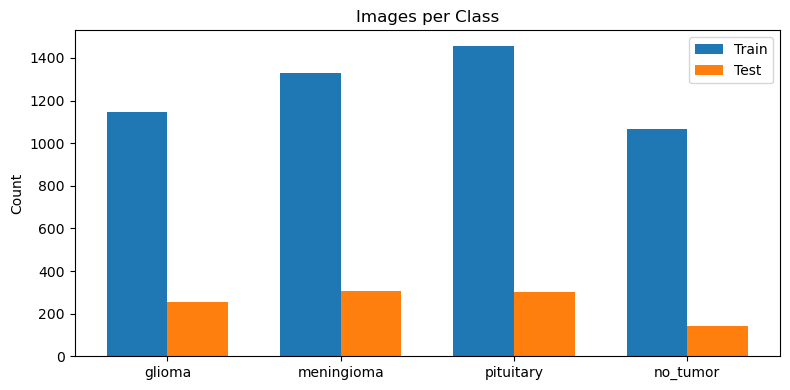

Train: {'glioma': 1147, 'meningioma': 1329, 'pituitary': 1457, 'no_tumor': 1067}
Test : {'glioma': 254, 'meningioma': 306, 'pituitary': 300, 'no_tumor': 140}


In [3]:
# =============================================================================
# 1. Class Distribution
# =============================================================================
# Count images per class across train/test splits to verify
# that the dataset is balanced and complete.
# Expected: ~5,000 train / ~1,000 test across 4 classes.
# =============================================================================

import matplotlib.pyplot as plt
import cv2

CLASSES = ['glioma', 'meningioma', 'pituitary', 'no_tumor']

splits = {}
for split in ['train', 'test']:
    counts = {}
    for cls in CLASSES:
        folder = CLF_PATH / split / cls
        counts[cls] = len(list(folder.glob('*.jpg')))
    splits[split] = counts

# Grouped bar chart
x = np.arange(len(CLASSES))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, [splits['train'][c] for c in CLASSES], w, label='Train')
ax.bar(x + w/2, [splits['test'][c]  for c in CLASSES], w, label='Test')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.set_ylabel('Count')
ax.set_title('Images per Class')
ax.legend()
plt.tight_layout()
plt.show()

print('Train:', splits['train'])
print('Test :', splits['test'])

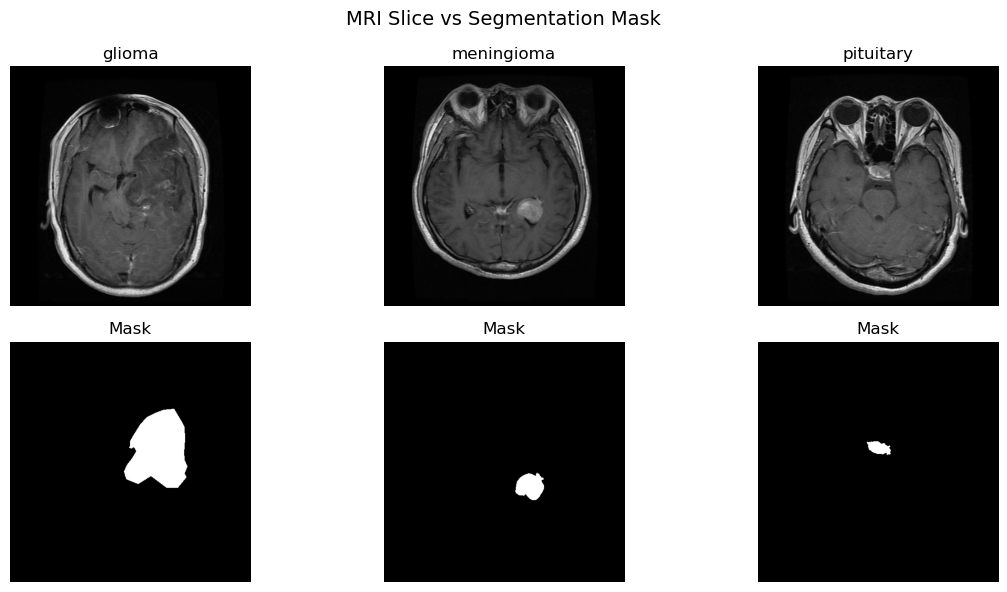

In [4]:
# =============================================================================
# 2. Sample Visualization — MRI Slices vs. Segmentation Masks
# =============================================================================
# Display one sample per tumor class (glioma, meningioma, pituitary)
# with its corresponding segmentation mask.
# Note: 'no_tumor' is excluded — no tumor region to segment.
# =============================================================================

SEG_CLASSES = ['glioma', 'meningioma', 'pituitary']
CODE_MAP = {'glioma': '_gl_', 'meningioma': '_me_', 'pituitary': '_pi_'}

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for i, cls in enumerate(SEG_CLASSES):
    img_dir  = SEG_PATH / 'train' / 'images'
    mask_dir = SEG_PATH / 'train' / 'masks'

    # Select one sample by matching the tumor code in the filename
    code   = CODE_MAP[cls]
    sample = next(f for f in sorted(img_dir.glob('*.jpg')) if code in f.name)

    img  = cv2.cvtColor(cv2.imread(str(sample)), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(mask_dir / sample.with_suffix('.png').name),
                      cv2.IMREAD_GRAYSCALE)

    axes[0, i].imshow(img)
    axes[0, i].set_title(cls)
    axes[0, i].axis('off')

    axes[1, i].imshow(mask, cmap='gray')
    axes[1, i].set_title('Mask')
    axes[1, i].axis('off')

fig.suptitle('MRI Slice vs Segmentation Mask', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# =============================================================================
# 3. Image Dimensions Consistency Check
# =============================================================================
# Verify whether all images share the same resolution.
# Inconsistent sizes may require resizing during preprocessing.
# =============================================================================

from collections import Counter

sizes = []
for img_path in (SEG_PATH / 'train' / 'images').glob('*.jpg'):
    h, w = cv2.imread(str(img_path)).shape[:2]
    sizes.append((h, w))

size_counts = Counter(sizes)
print(f'Total train images: {len(sizes)}')
print(f'Unique sizes: {len(size_counts)}')
for size, count in size_counts.most_common(5):
    print(f'  {size[1]}x{size[0]} — {count} images')

Total train images: 3933
Unique sizes: 124
  512x512 — 3766 images
  256x256 — 25 images
  225x225 — 8 images
  442x442 — 4 images
  455x500 — 3 images


### 1.1  Class-Distribution Pie Charts
Visualize the **proportion** of each class within the train and test
splits using pie charts — complements the bar chart above.

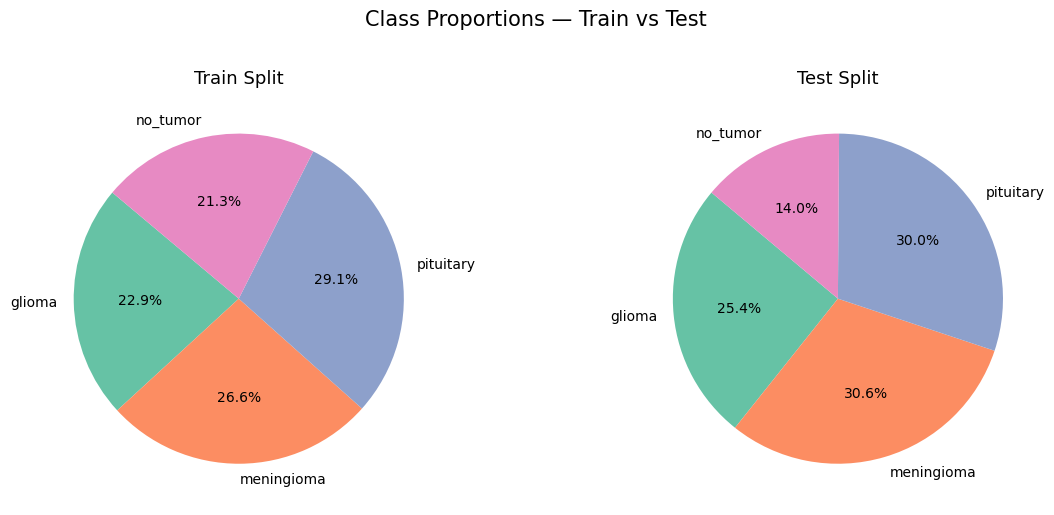

In [6]:
# =============================================================================
# 1.1 Pie Charts — Train & Test Class Proportions
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, split in zip(axes, ['train', 'test']):
    labels = list(splits[split].keys())
    sizes  = list(splits[split].values())
    colors = plt.cm.Set2.colors[:len(labels)]
    wedges, texts, autotexts = ax.pie(
        sizes, labels=labels, autopct='%1.1f%%',
        colors=colors, startangle=140, textprops={'fontsize': 10})
    ax.set_title(f'{split.capitalize()} Split', fontsize=13)

fig.suptitle('Class Proportions — Train vs Test', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 1.2  Multi-Sample Grid
Display a **4 × 3 grid** of random MRI samples (4 per class) to give a
broader view of the dataset variety.

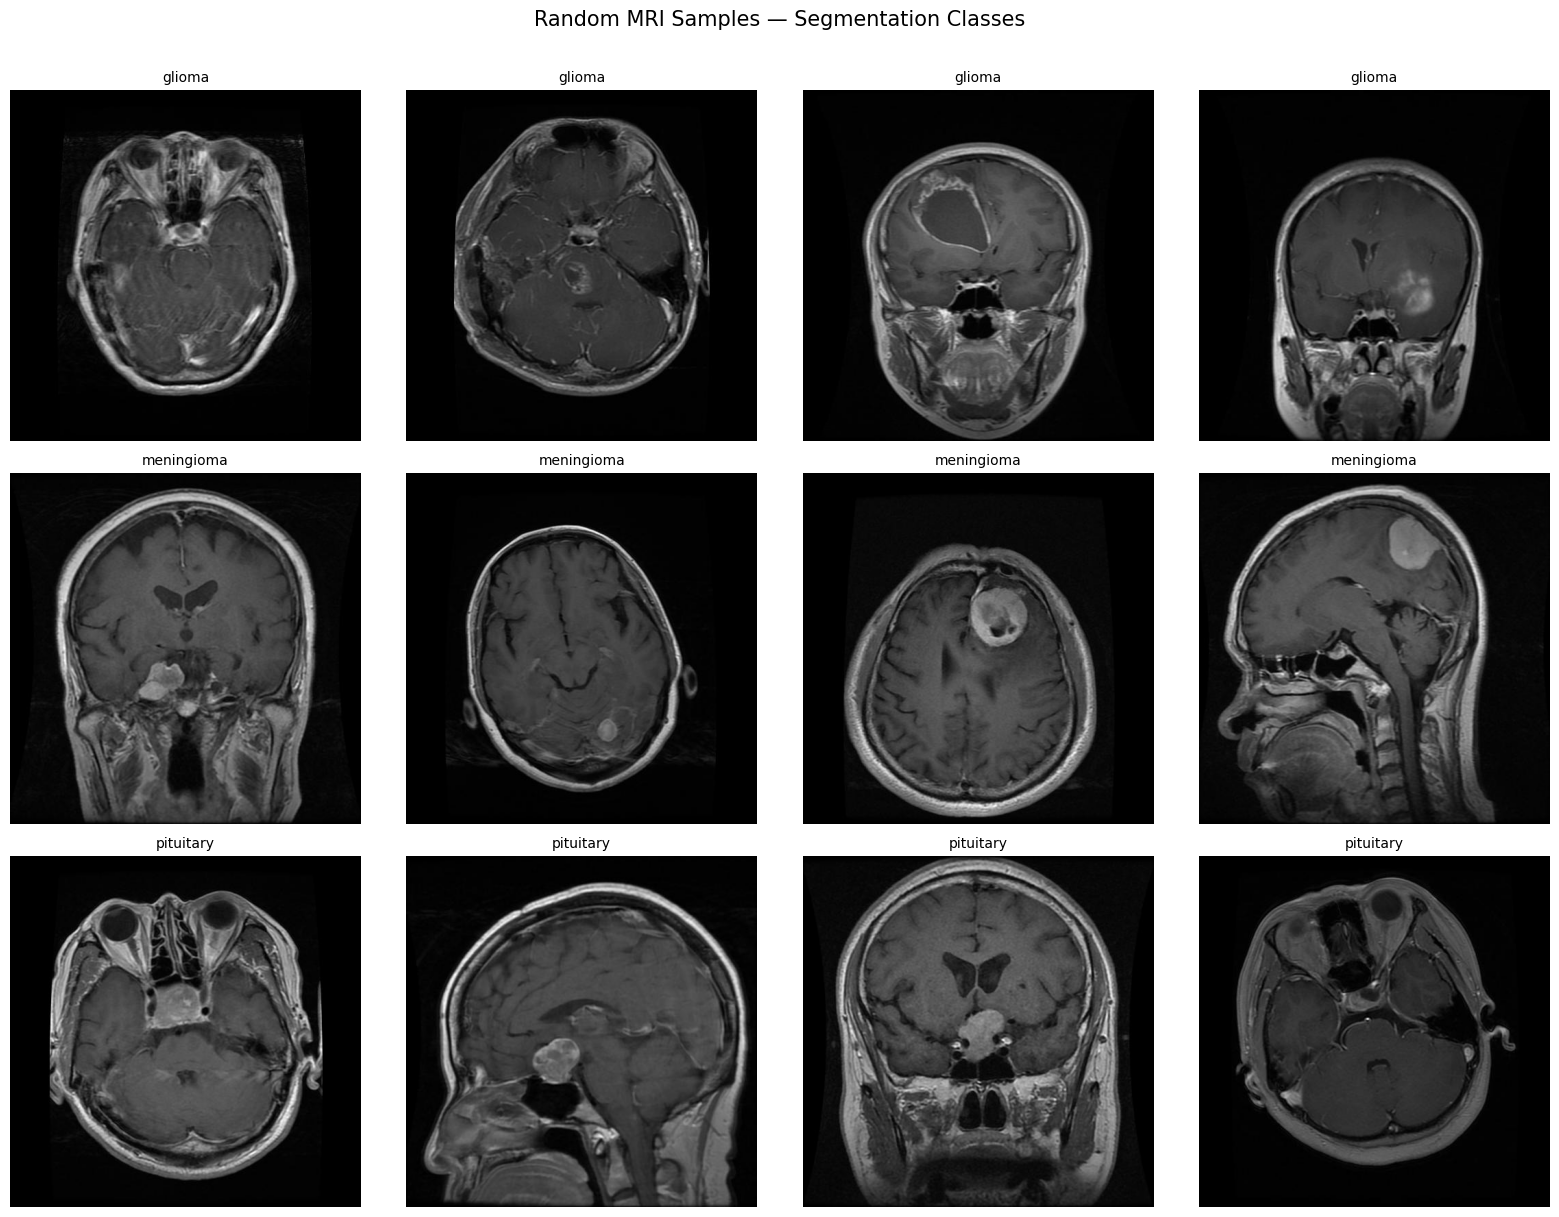

In [7]:
# =============================================================================
# 1.2 Multi-Sample MRI Grid (4 per class)
# =============================================================================

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for row, cls in enumerate(SEG_CLASSES):
    code = CODE_MAP[cls]
    img_dir = SEG_PATH / 'train' / 'images'
    candidates = sorted([f for f in img_dir.glob('*.jpg') if code in f.name])
    samples = random.sample(candidates, min(4, len(candidates)))
    for col, sample in enumerate(samples):
        img = cv2.cvtColor(cv2.imread(str(sample)), cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'{cls}', fontsize=10)
        axes[row, col].axis('off')

fig.suptitle('Random MRI Samples — Segmentation Classes', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 1.3  Image Dimension Distribution
A **bar chart** of the top-10 image resolutions found in the training
segmentation images — clearer than the text listing above.

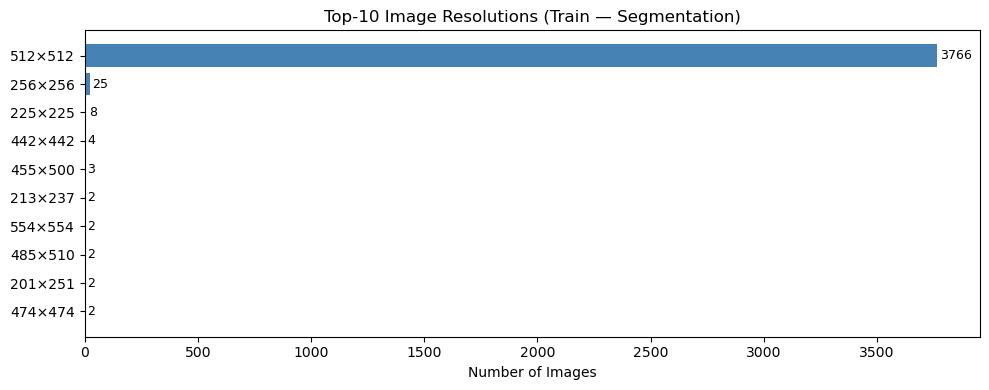

In [8]:
# =============================================================================
# 1.3 Image Dimension Distribution (bar chart)
# =============================================================================

dim_labels = [f'{w}×{h}' for (h, w), _ in size_counts.most_common(10)]
dim_counts = [c for _, c in size_counts.most_common(10)]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(dim_labels[::-1], dim_counts[::-1], color='steelblue')
ax.set_xlabel('Number of Images')
ax.set_title('Top-10 Image Resolutions (Train — Segmentation)')
for bar in bars:
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 1.4  MRI + Mask Overlay
Overlay the segmentation mask on top of the original MRI image with a
semi-transparent colormap.  This clearly shows what the masks capture.

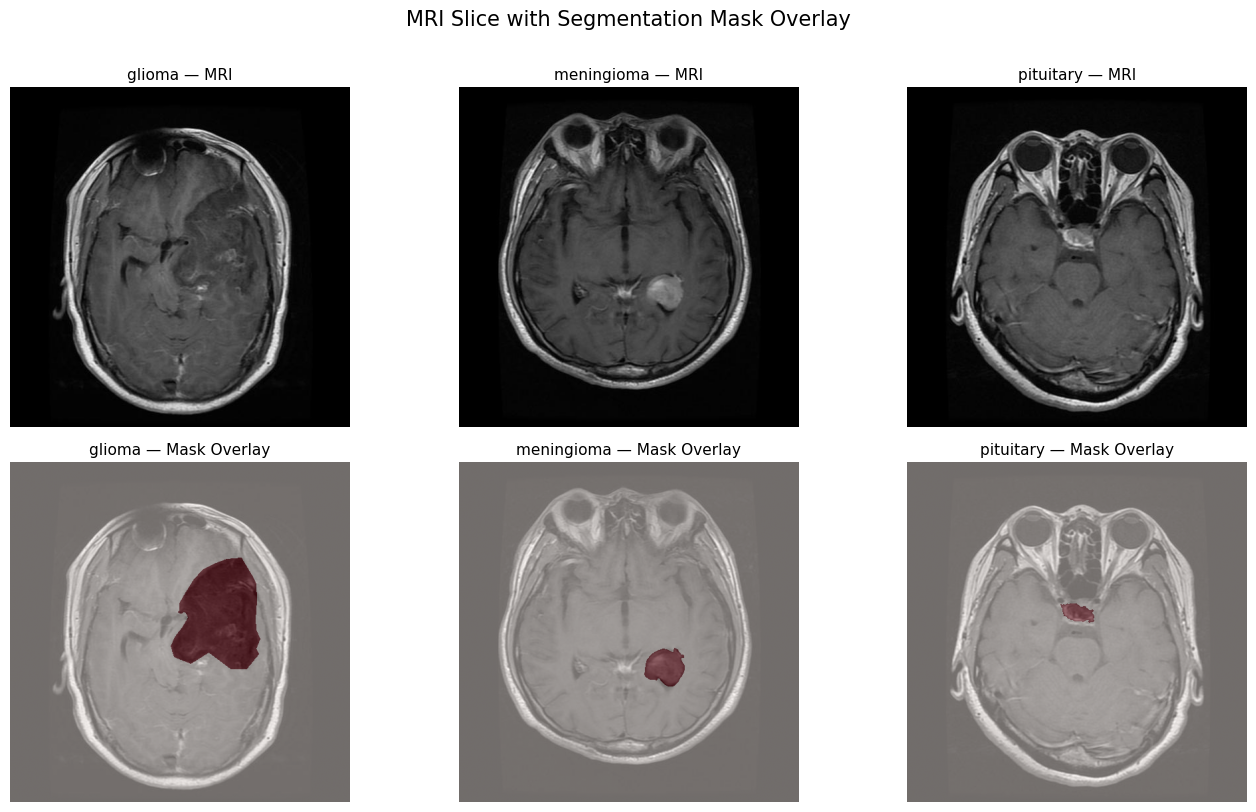

In [9]:
# =============================================================================
# 1.4 MRI + Mask Overlay Visualization
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, cls in enumerate(SEG_CLASSES):
    code   = CODE_MAP[cls]
    img_dir  = SEG_PATH / 'train' / 'images'
    mask_dir = SEG_PATH / 'train' / 'masks'
    sample = next(f for f in sorted(img_dir.glob('*.jpg')) if code in f.name)

    img  = cv2.cvtColor(cv2.imread(str(sample)), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(mask_dir / sample.with_suffix('.png').name),
                      cv2.IMREAD_GRAYSCALE)

    # Top row: plain MRI
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'{cls} — MRI', fontsize=11)
    axes[0, i].axis('off')

    # Bottom row: MRI + overlay
    axes[1, i].imshow(img)
    axes[1, i].imshow(mask, cmap='Reds', alpha=0.45)
    axes[1, i].set_title(f'{cls} — Mask Overlay', fontsize=11)
    axes[1, i].axis('off')

fig.suptitle('MRI Slice with Segmentation Mask Overlay', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## Feature Extraction

**Goal:** Extract geometric and texture features from segmentation masks to build a structured tabular dataset for classification.

**Features:**
- **Geometric:** area, perimeter, solidity, eccentricity, bounding box aspect ratio.
- **Texture (GLCM):** contrast, correlation, energy, homogeneity (computed on bounding-box crop for accuracy).
- **Metadata:** anatomical view (axial / coronal / sagittal), tumor label.

> **Note:** For `no_tumor` images (which have no segmentation mask), all geometric and texture features are set to **0.0** — the absence of a tumor region is itself the discriminative signal.

In [10]:
# =============================================================================
# 4. Feature Extraction Pipeline
# =============================================================================
# For each MRI image with a segmentation mask, extract:
#   - Geometric features  : area, perimeter, solidity, eccentricity, bbox ratio
#   - Texture features    : GLCM contrast, correlation, energy, homogeneity
#                           (GLCM is computed on the bounding-box crop of the mask)
#   - Metadata            : anatomical view and tumor label (from filename)
#
# For no_tumor images (no mask), all features are set to 0.0.
# The output is a pandas DataFrame — one row per image.
# =============================================================================

import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import regionprops, label as sk_label

# --- Filename parser ---
TUMOR_MAP = {'gl': 'glioma', 'me': 'meningioma', 'pi': 'pituitary', 'no': 'no_tumor'}
VIEW_MAP  = {'ax': 'axial',  'co': 'coronal',    'sa': 'sagittal'}

def parse_filename(name):
    """Extract split, label, and view from BRISC filename."""
    parts = name.stem.split('_')   # e.g. brisc2025_train_00001_gl_ax_t1
    return {
        'split': parts[1],
        'label': TUMOR_MAP[parts[3]],
        'view' : VIEW_MAP[parts[4]],
    }

# --- Geometric features ---
def geometric_features(mask):
    """Compute shape-based features from a binary mask."""
    labeled = sk_label(mask > 0)
    regions = regionprops(labeled)
    if not regions:
        return {k: 0.0 for k in ['area', 'perimeter', 'solidity',
                                  'eccentricity', 'bbox_ratio']}
    r = max(regions, key=lambda x: x.area)   # largest connected component
    h = r.bbox[2] - r.bbox[0]
    w = r.bbox[3] - r.bbox[1]
    return {
        'area'        : r.area,
        'perimeter'   : r.perimeter,
        'solidity'    : r.solidity,
        'eccentricity': r.eccentricity,
        'bbox_ratio'  : h / w if w > 0 else 0.0,
    }

# --- Texture features (GLCM) ---
def texture_features(gray_img, mask):
    """Compute GLCM texture features within the masked region (cropped to bbox)."""
    coords = np.argwhere(mask > 0)
    if coords.size == 0:
        return {k: 0.0 for k in ['contrast', 'correlation', 'energy', 'homogeneity']}
    # Crop to mask bounding box for more meaningful texture
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    crop_gray = gray_img[y0:y1, x0:x1]
    crop_mask = (mask[y0:y1, x0:x1] > 0).astype(np.uint8)
    roi = cv2.bitwise_and(crop_gray, crop_gray, mask=crop_mask)
    glcm = graycomatrix(roi, distances=[1], angles=[0], levels=256,
                        symmetric=True, normed=True)
    return {
        'contrast'   : graycoprops(glcm, 'contrast')[0, 0],
        'correlation': graycoprops(glcm, 'correlation')[0, 0],
        'energy'     : graycoprops(glcm, 'energy')[0, 0],
        'homogeneity': graycoprops(glcm, 'homogeneity')[0, 0],
    }

print('Feature functions defined ✅')

Feature functions defined ✅


In [11]:
# =============================================================================
# 5. Run Feature Extraction (Train + Test)
# =============================================================================
# Loop over all images (segmented + no_tumor) and build
# the final tabular dataset with all 4 classes.
# =============================================================================

def extract_dataset_features(splits=['train', 'test']):
    records = []
    
    for split in splits:
        # --- Tumor classes (have segmentation masks) ---
        img_dir  = SEG_PATH / split / 'images'
        mask_dir = SEG_PATH / split / 'masks'

        img_files = sorted(img_dir.glob('*.jpg'))
        print(f'Processing {split} (segmented): {len(img_files)} images ...')

        for img_path in img_files:
            mask_path = mask_dir / img_path.with_suffix('.png').name
            if not mask_path.exists():
                continue

            # Read image and mask
            gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

            # Parse filename metadata
            meta = parse_filename(img_path)

            # Extract features
            geo  = geometric_features(mask)
            tex  = texture_features(gray, mask)

            records.append({**meta, **geo, **tex, 'filename': img_path.name})

        # --- No-tumor class (no masks → all features zero) ---
        nt_dir   = CLF_PATH / split / 'no_tumor'
        nt_files = sorted(nt_dir.glob('*.jpg'))
        print(f'Processing {split} (no_tumor) : {len(nt_files)} images ...')

        for img_path in nt_files:
            meta = parse_filename(img_path)
            geo  = {k: 0.0 for k in ['area', 'perimeter', 'solidity',
                                      'eccentricity', 'bbox_ratio']}
            tex  = {k: 0.0 for k in ['contrast', 'correlation',
                                      'energy', 'homogeneity']}
            records.append({**meta, **geo, **tex, 'filename': img_path.name})
            
    return pd.DataFrame(records)

df = extract_dataset_features(['train', 'test'])
print(f'\nDataset shape: {df.shape}')
df.head()

Processing train (segmented): 3933 images ...
Processing train (no_tumor) : 1067 images ...
Processing test (segmented): 860 images ...
Processing test (no_tumor) : 140 images ...

Dataset shape: (6000, 13)


,split,label,view,area,perimeter,solidity,eccentricity,bbox_ratio,contrast,correlation,energy,homogeneity,filename
0,train,glioma,axial,17058.0,1057.850901,0.843537,0.644764,1.166667,390.994880,0.806246,0.258063,0.468404,brisc2025_train_00001_gl_ax_t1.jpg
1,train,glioma,axial,16414.0,895.589971,0.890130,0.774690,1.375000,167.162983,0.826457,0.239834,0.538273,brisc2025_train_00002_gl_ax_t1.jpg
2,train,glioma,axial,3036.0,415.682287,0.804238,0.414271,0.888889,514.777289,0.899717,0.244416,0.343988,brisc2025_train_00003_gl_ax_t1.jpg
3,train,glioma,axial,2624.0,485.836616,0.686552,0.836285,0.613636,234.275452,0.946164,0.389953,0.483226,brisc2025_train_00004_gl_ax_t1.jpg
4,train,glioma,axial,3560.0,522.872150,0.750738,0.712625,1.097222,454.336603,0.871825,0.451887,0.537264,brisc2025_train_00005_gl_ax_t1.jpg


In [12]:
# =============================================================================
# 6. Save Tabular Dataset
# =============================================================================
# Export the extracted features as CSV files:
#   - features.csv      : full dataset with all columns (notebook reference)
#   - azure_train.csv   : training split for Azure AutoML (no split/filename)
#   - azure_test.csv    : test split for Azure AutoML    (no split/filename)
# =============================================================================

# Full reference dataset
output_path = DATASET_PATH / 'features.csv'
df.to_csv(output_path, index=False)

# Azure-ready datasets — drop non-feature columns (split, filename)
azure_cols  = [c for c in df.columns if c not in ('split', 'filename')]
train_azure = df[df['split'] == 'train'][azure_cols]
test_azure  = df[df['split'] == 'test'][azure_cols]

train_azure.to_csv(DATASET_PATH / 'azure_train.csv', index=False)
test_azure.to_csv(DATASET_PATH / 'azure_test.csv', index=False)

print(f'Saved full dataset : {output_path}  — shape {df.shape}')
print(f'Saved Azure train  : azure_train.csv — shape {train_azure.shape}')
print(f'Saved Azure test   : azure_test.csv  — shape {test_azure.shape}')
print(f'\nColumns (Azure): {list(azure_cols)}')
print(f'\nLabel distribution (full):')
print(df['label'].value_counts())

Saved full dataset : brisc2025/features.csv  — shape (6000, 13)
Saved Azure train  : azure_train.csv — shape (5000, 11)
Saved Azure test   : azure_test.csv  — shape (1000, 11)

Columns (Azure): ['label', 'view', 'area', 'perimeter', 'solidity', 'eccentricity', 'bbox_ratio', 'contrast', 'correlation', 'energy', 'homogeneity']

Label distribution (full):
label
pituitary     1757
meningioma    1635
glioma        1401
no_tumor      1207
Name: count, dtype: int64


## Feature Analysis & Visualization

Now that the features are extracted, let's **visualize** them to
understand the data distribution, correlations, and class separability.

### 2.1  Feature Distributions (Histograms + KDE)
Show the distribution of each numeric feature, colored by tumor label.

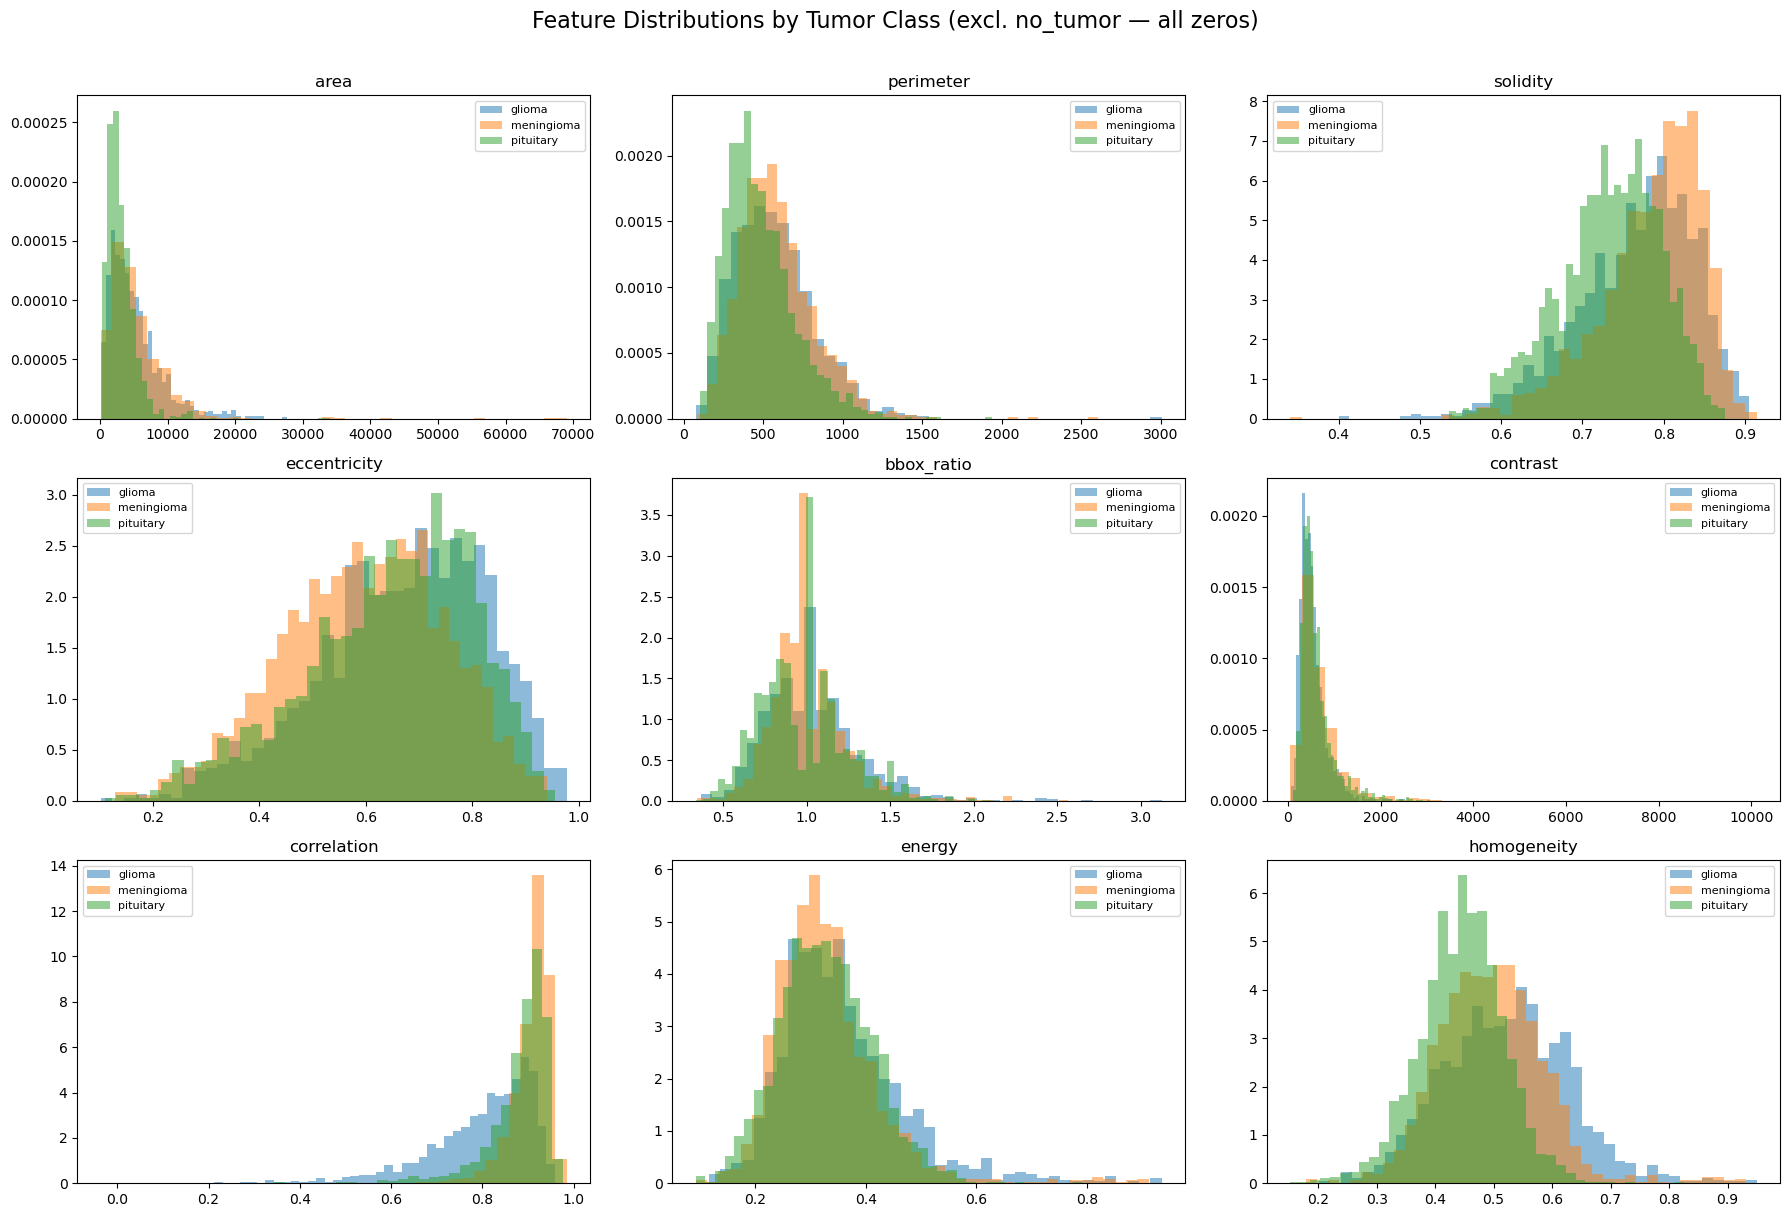

In [22]:
# =============================================================================
# 2.1 Feature Distributions — Histograms with KDE
# =============================================================================
# NOTE: 'no_tumor' is excluded from these plots because all its features are
# 0.0 by design (no segmentation mask). Including it creates a massive spike
# at zero that crushes the y-axis and hides the real tumor distributions.
# =============================================================================
import seaborn as sns

FEATURES = ['area', 'perimeter', 'solidity', 'eccentricity',
            'bbox_ratio', 'contrast', 'correlation', 'energy', 'homogeneity']

TUMOR_CLASSES = ['glioma', 'meningioma', 'pituitary']
df_tumor = df[df['label'] != 'no_tumor']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for ax, feat in zip(axes.flat, FEATURES):
    for label in TUMOR_CLASSES:
        subset = df_tumor[df_tumor['label'] == label]
        ax.hist(subset[feat], bins=40, alpha=0.5, label=label, density=True)
    ax.set_title(feat, fontsize=12)
    ax.legend(fontsize=8)

fig.suptitle('Feature Distributions by Tumor Class (excl. no_tumor — all zeros)',
             fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 2.2  Feature Correlation Heatmap
Pearson correlation matrix of all 9 numeric features.

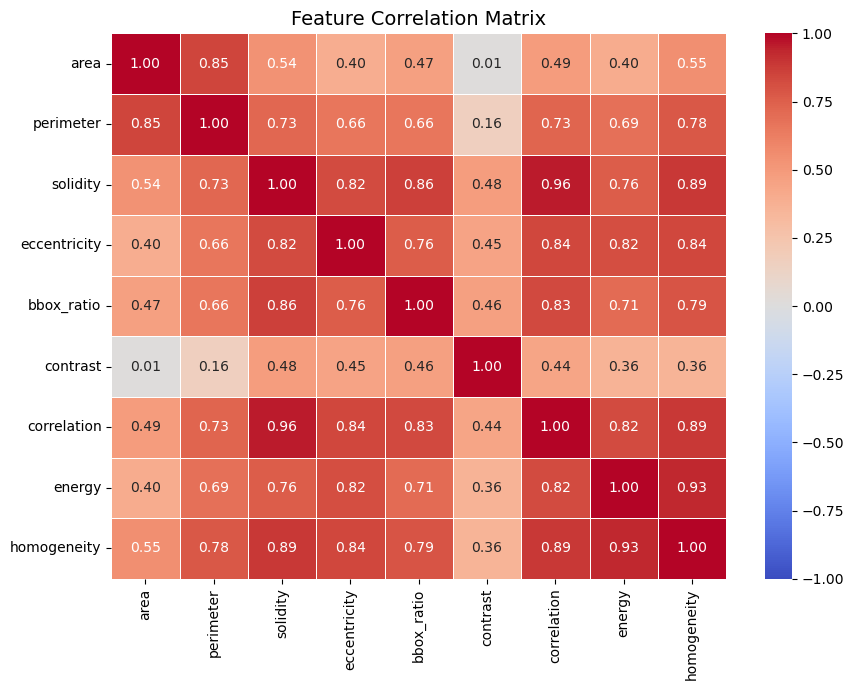

In [14]:
# =============================================================================
# 2.2 Correlation Heatmap
# =============================================================================

corr = df[FEATURES].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

### 2.3  Box Plots per Class
For each feature, a box plot split by tumor label.  Highlights median,
quartiles, and outliers.

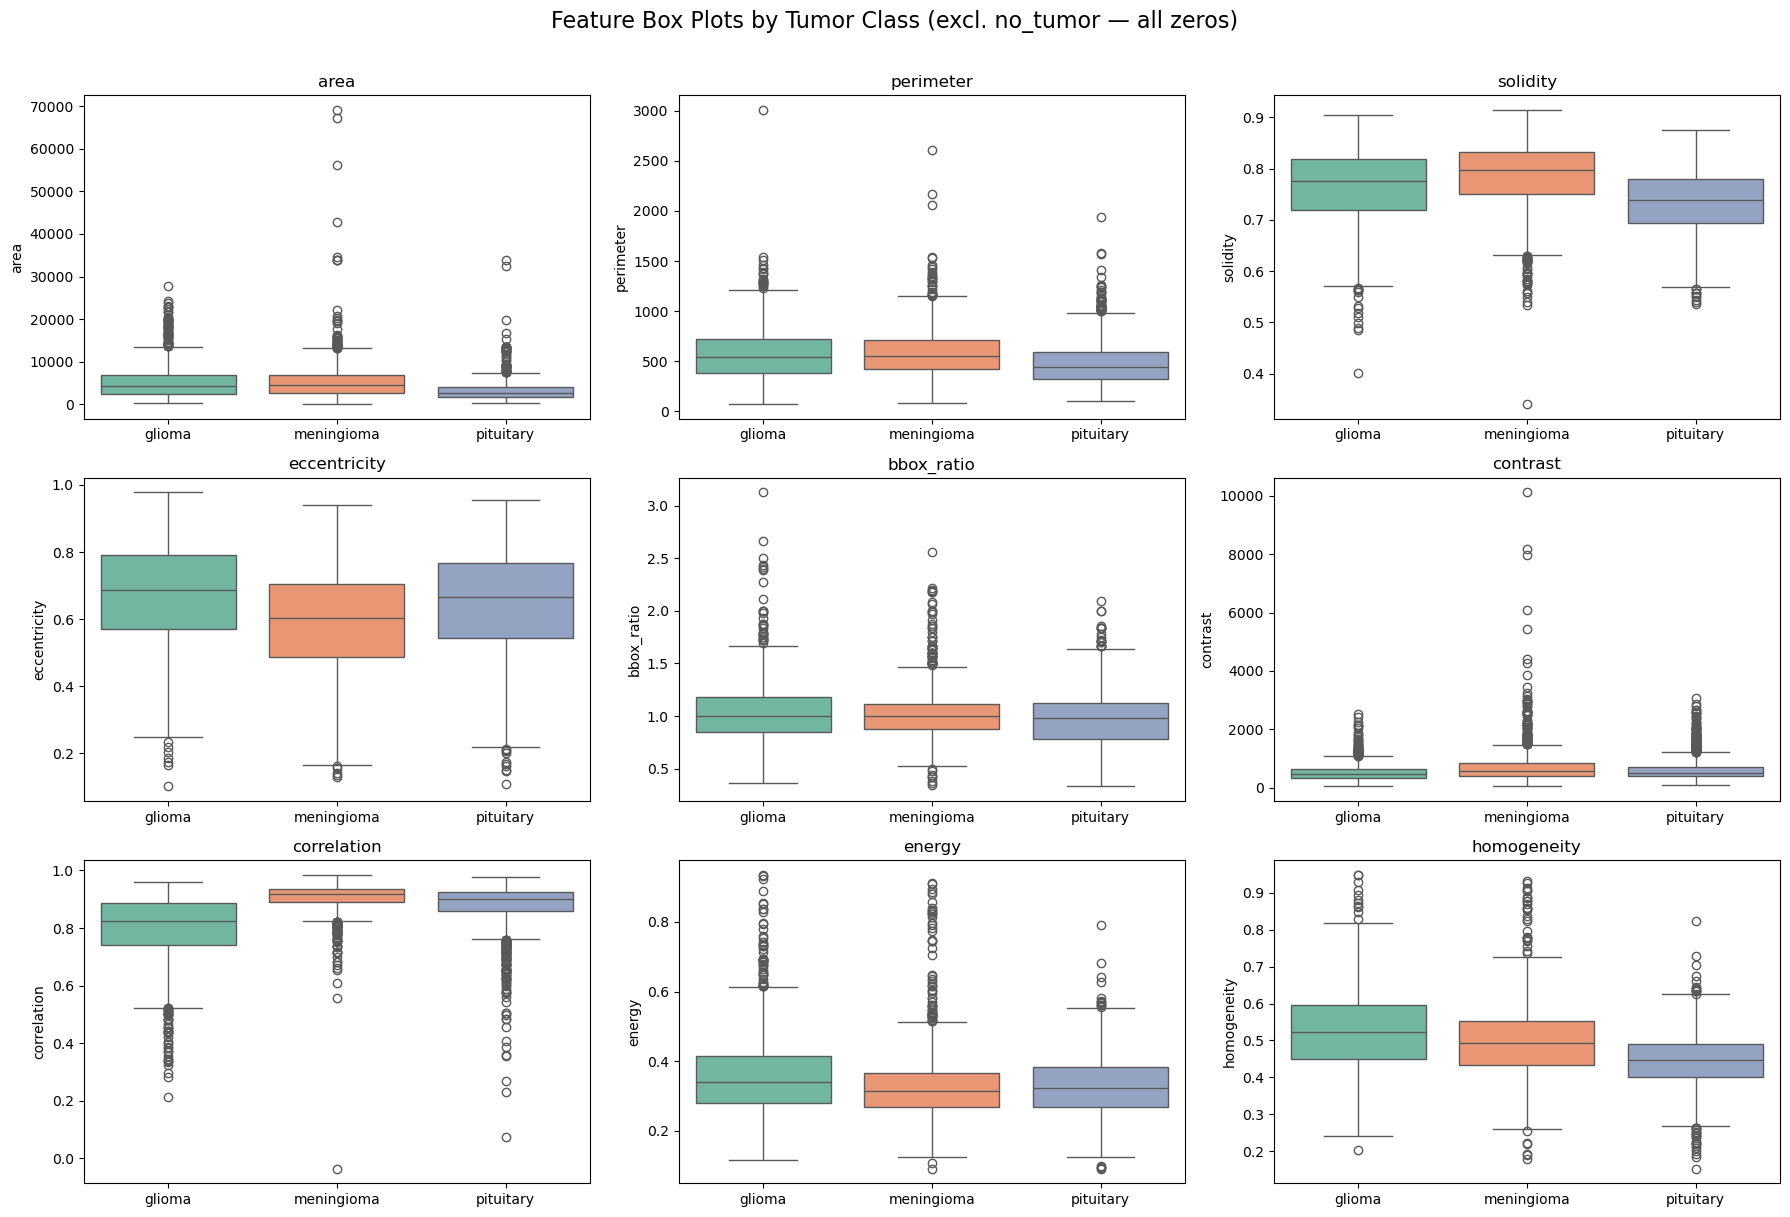

In [23]:
# =============================================================================
# 2.3 Box Plots — Features by Class (excl. no_tumor)
# =============================================================================
# no_tumor excluded: all features are 0.0, which collapses every box to a
# flat line at zero and compresses the y-axis range of the tumor classes.
# =============================================================================

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for ax, feat in zip(axes.flat, FEATURES):
    sns.boxplot(data=df_tumor, x='label', y=feat, ax=ax,
                palette='Set2', hue='label', legend=False)
    ax.set_title(feat, fontsize=12)
    ax.set_xlabel('')

fig.suptitle('Feature Box Plots by Tumor Class (excl. no_tumor — all zeros)',
             fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 2.4  Anatomical View Distribution
Stacked bar chart: how many images of each **view** (axial / coronal /
sagittal) exist per class.

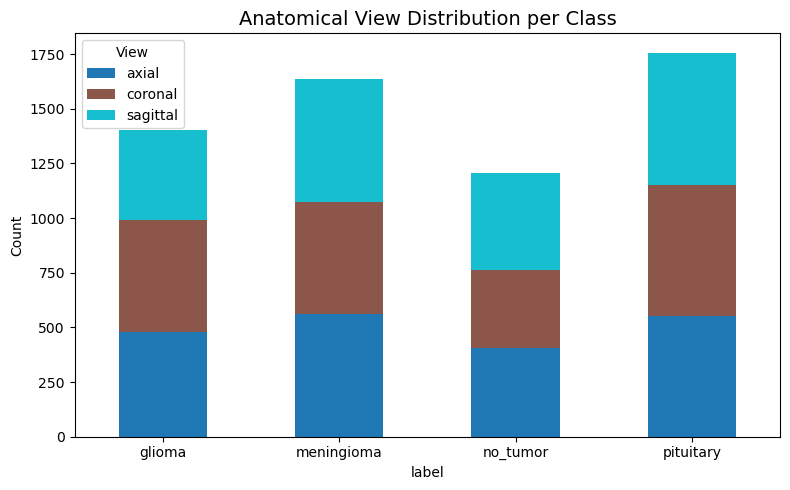

In [16]:
# =============================================================================
# 2.4 View Distribution by Class
# =============================================================================

view_counts = df.groupby(['label', 'view']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))
view_counts.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_ylabel('Count')
ax.set_title('Anatomical View Distribution per Class', fontsize=14)
ax.legend(title='View')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 2.5  Pair Plot (Selected Features)
Scatter matrix of the 4 most informative geometric + texture features,
colored by label.  Reveals pairwise class separation.

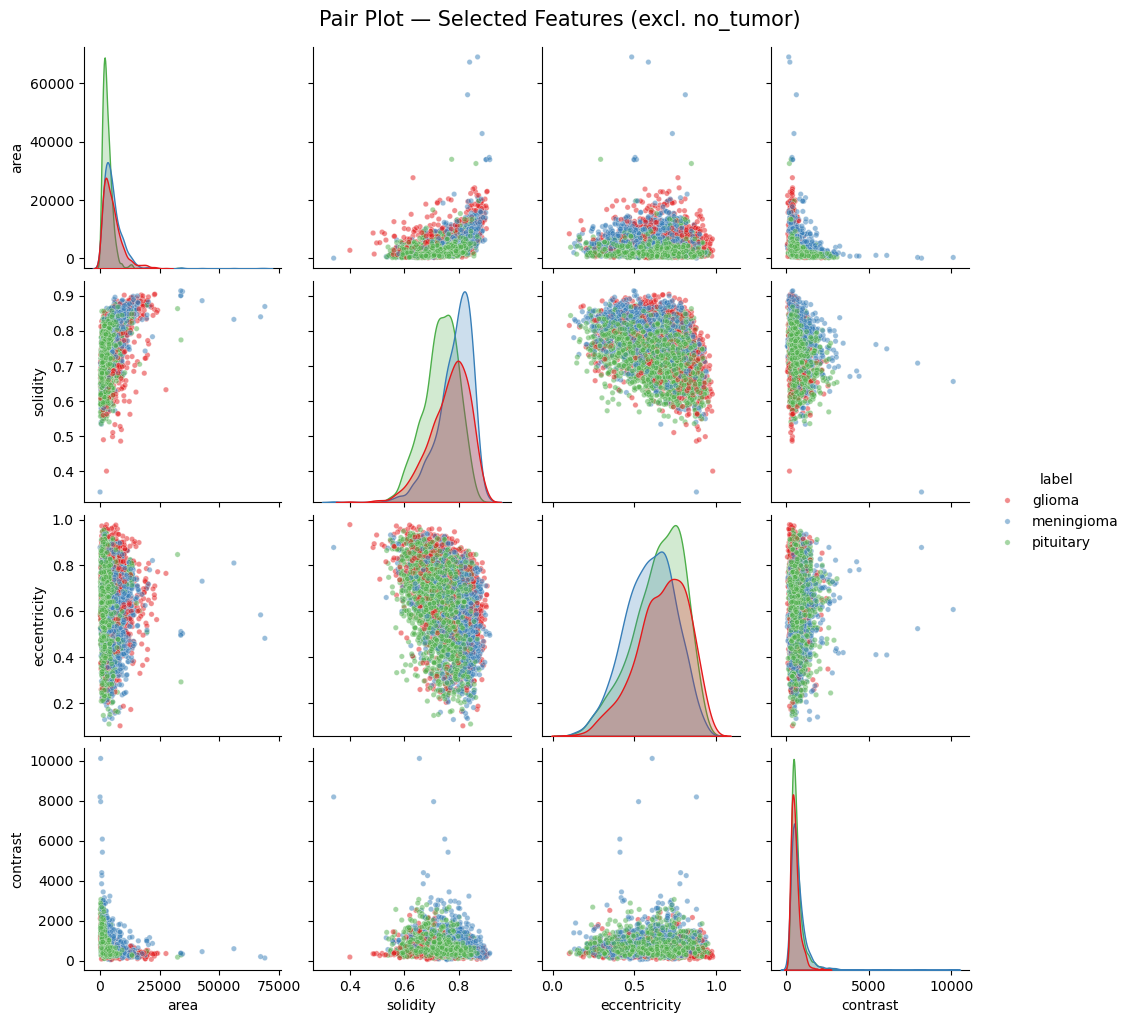

In [24]:
# =============================================================================
# 2.5 Pair Plot — Selected Features (excl. no_tumor)
# =============================================================================

pair_features = ['area', 'solidity', 'eccentricity', 'contrast']

g = sns.pairplot(df_tumor[pair_features + ['label']],
                 hue='label', palette='Set1',
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 15})
g.figure.suptitle('Pair Plot — Selected Features (excl. no_tumor)',
                   y=1.02, fontsize=15)
plt.show()

## Local Baseline Model (Benchmarking)

> **Note:** This section trains a local **Random Forest** classifier as a **baseline benchmark** only.
> The real model selection and hyperparameter optimization will be performed via **Azure AutoML** in the next phase.
> The purpose here is to (1) verify the extracted features carry predictive signal, (2) rank feature importance,
> and (3) establish a minimum accuracy threshold that Azure AutoML should exceed.

**Goal:** Train a tuned Random Forest on all extracted features (no outlier removal, no feature dropping) and evaluate on the held-out test split.

**Pipeline:**
1. **Prepare data** — use the full training set (no IQR filtering; medical extremes are valid signal).
2. **GridSearchCV** — auto-tune key hyperparameters with 5-fold cross-validation.
3. **Feature importance** — rank features via Mean Decrease in Impurity (MDI).
4. **Classification report + confusion matrix** — per-class precision / recall / F1 on the test split.


In [18]:
# =============================================================================
# Step 1 — Prepare Training & Test Data (NO outlier removal)
# =============================================================================
# IMPORTANT: We do NOT remove outliers via IQR. In medical imaging, extreme
# values (very small or very large tumors) are clinically valid and carry
# important diagnostic signal. Removing them would bias the model.
#
# Similarly, we do NOT drop correlated features. Random Forest is robust to
# multicollinearity, and features like 'perimeter' and 'area' each carry
# complementary shape information that aids classification.
# =============================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

# ---- Split raw data (full dataset, no filtering) ----
train_df = df[df['split'] == 'train'].copy()
test_df  = df[df['split'] == 'test'].copy()

print(f"Training set: {len(train_df)} rows (full, no outlier removal)")
print(f"Test set    : {len(test_df)} rows")

# ---- Encode labels ----
le = LabelEncoder()
y_train = le.fit_transform(train_df['label'])
X_train = train_df[FEATURES].copy()

# Use ALL 9 extracted features — no correlation-based dropping
ACTIVE_FEATURES = list(X_train.columns)
print(f"\n✅ Active features ({len(ACTIVE_FEATURES)}): {ACTIVE_FEATURES}")


Training set: 5000 rows (full, no outlier removal)
Test set    : 1000 rows

✅ Active features (9): ['area', 'perimeter', 'solidity', 'eccentricity', 'bbox_ratio', 'contrast', 'correlation', 'energy', 'homogeneity']


### GridSearchCV — Hyperparameter Tuning & Feature Importances
Train a single **Random Forest** with `GridSearchCV` (5-fold CV) and extract feature importances from the best estimator.

✅ Using all 9 features: ['area', 'perimeter', 'solidity', 'eccentricity', 'bbox_ratio', 'contrast', 'correlation', 'energy', 'homogeneity']
🔍 Running GridSearchCV (this may take a moment) ...
✅ Best hyperparameters : {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 20}
✅ Best CV accuracy     : 0.7950


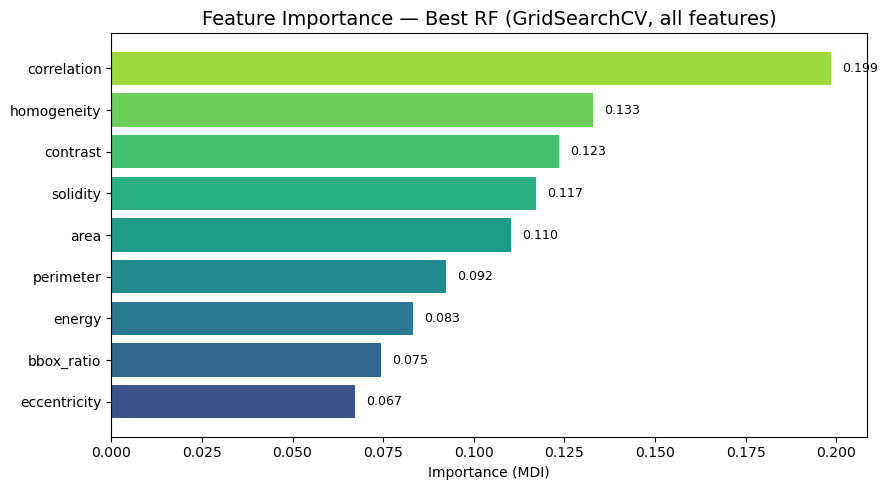


Feature Importance Ranking:
-----------------------------------
  correlation      0.1986
  homogeneity      0.1330
  contrast         0.1235
  solidity         0.1171
  area             0.1104
  perimeter        0.0924
  energy           0.0832
  bbox_ratio       0.0745
  eccentricity     0.0674


In [19]:
# =============================================================================
# Step 2 — GridSearchCV: Tune & Train Random Forest
# =============================================================================
# Train a single Random Forest via GridSearchCV (5-fold CV).
# class_weight='balanced' compensates for uneven class sizes.
# All 9 features are used — RF handles collinearity gracefully.
# =============================================================================

X_train_sel = X_train[ACTIVE_FEATURES]

print(f"✅ Using all {len(ACTIVE_FEATURES)} features: {ACTIVE_FEATURES}")
print("🔍 Running GridSearchCV (this may take a moment) ...")

param_grid = {
    'max_depth'        : [3, 5, 7, 10],
    'min_samples_leaf' : [4, 10, 20],
    'min_samples_split': [10, 20, 40],
}

grid_search = GridSearchCV(
    RandomForestClassifier(
        n_estimators=500,
        max_features='sqrt',
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
    ),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0,
)
grid_search.fit(X_train_sel, y_train)

rf = grid_search.best_estimator_

print(f"✅ Best hyperparameters : {grid_search.best_params_}")
print(f"✅ Best CV accuracy     : {grid_search.best_score_:.4f}")

# =============================================================================
# Step 3 — Feature Importances (from best estimator)
# =============================================================================

importances = rf.feature_importances_
sorted_idx  = importances.argsort()
sorted_feat = [ACTIVE_FEATURES[i] for i in sorted_idx]
sorted_imp  = importances[sorted_idx]

fig, ax = plt.subplots(figsize=(9, 5))
colors  = plt.cm.viridis(np.linspace(0.25, 0.85, len(sorted_feat)))
bars    = ax.barh(sorted_feat, sorted_imp, color=colors)

for bar, val in zip(bars, sorted_imp):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Importance (MDI)')
ax.set_title('Feature Importance — Best RF (GridSearchCV, all features)', fontsize=14)
plt.tight_layout()
plt.show()

print('\nFeature Importance Ranking:')
print('-' * 35)
for feat, imp in zip(reversed(sorted_feat), reversed(sorted_imp)):
    print(f'  {feat:15s}  {imp:.4f}')


### Evaluate on Test Split
We use the held-out test split to generate a full classification report and a confusion matrix heatmap.

Final RF train accuracy: 0.8878
Final RF test  accuracy: 0.7500
⚠️  Overfit gap: 0.138 (train − test). Consider more regularization.

Classification Report (test set):
              precision    recall  f1-score   support

      glioma       0.78      0.63      0.70       254
  meningioma       0.74      0.77      0.76       306
    no_tumor       1.00      1.00      1.00       140
   pituitary       0.64      0.71      0.67       300

    accuracy                           0.75      1000
   macro avg       0.79      0.78      0.78      1000
weighted avg       0.76      0.75      0.75      1000



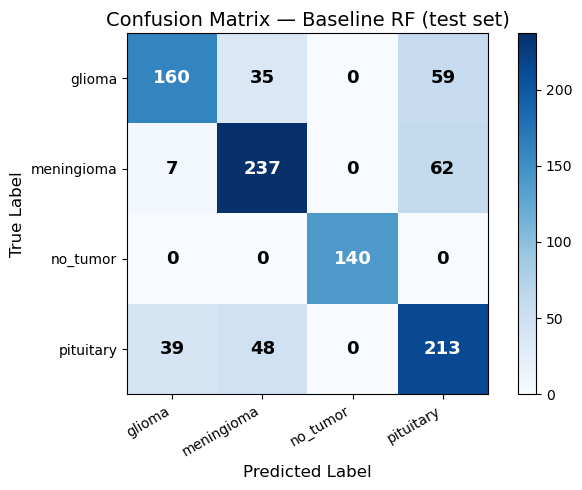

In [20]:
# =============================================================================
# Step 4 — Evaluate final model on test split
#           (uses all 9 features + best RF from GridSearchCV)
# =============================================================================

print(f'Final RF train accuracy: {rf.score(X_train_sel, y_train):.4f}')

if len(test_df) > 0:
    y_test     = le.transform(test_df['label'])
    X_test_sel = test_df[ACTIVE_FEATURES]

    y_pred = rf.predict(X_test_sel)

    print(f'Final RF test  accuracy: {rf.score(X_test_sel, y_test):.4f}')

    gap = rf.score(X_train_sel, y_train) - rf.score(X_test_sel, y_test)
    if gap > 0.10:
        print(f'⚠️  Overfit gap: {gap:.3f} (train − test). Consider more regularization.')
    else:
        print(f'✅  Train–test gap: {gap:.3f} — within acceptable range.')

    print('\nClassification Report (test set):')
    print('=' * 55)
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm  = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    im  = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax)

    classes    = le.classes_
    tick_marks = np.arange(len(classes))
    ax.set_xticks(tick_marks); ax.set_xticklabels(classes, rotation=30, ha='right')
    ax.set_yticks(tick_marks); ax.set_yticklabels(classes)

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j],
                    ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black',
                    fontsize=13, fontweight='bold')

    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label',      fontsize=12)
    ax.set_title('Confusion Matrix — Baseline RF (test set)', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No test split found — skipping evaluation metrics.')


## Export Final Dataset (Bridge to Azure)

Save the complete feature dataset as a single CSV ready for upload to **Azure Machine Learning Studio**.
The file contains all 9 numeric features, the categorical `view` column, and the `label` target — one row per image.

In [21]:
# =============================================================================
# Export — BRISC_Features_Dataset.csv
# =============================================================================
# Columns kept : label, view, + all 9 numeric features
# Columns dropped : split, filename (not needed for Azure AutoML)
# =============================================================================

export_cols = ['label', 'view'] + FEATURES
export_df   = df[export_cols].copy()

# Quick sanity checks before saving
assert export_df.isnull().sum().sum() == 0, "Unexpected NaN values!"
assert export_df.shape[0] == 6000, f"Expected 6000 rows, got {export_df.shape[0]}"

export_path = 'BRISC_Features_Dataset.csv'
export_df.to_csv(export_path, index=False)

print(f"✅ Exported: {export_path}")
print(f"   Shape   : {export_df.shape}")
print(f"   Columns : {list(export_df.columns)}")
print(f"\n   Label distribution:")
print(export_df['label'].value_counts().to_string())
print(f"\n📌 Upload this file to Azure ML Studio as a Data Asset.")

✅ Exported: BRISC_Features_Dataset.csv
   Shape   : (6000, 11)
   Columns : ['label', 'view', 'area', 'perimeter', 'solidity', 'eccentricity', 'bbox_ratio', 'contrast', 'correlation', 'energy', 'homogeneity']

   Label distribution:
label
pituitary     1757
meningioma    1635
glioma        1401
no_tumor      1207

📌 Upload this file to Azure ML Studio as a Data Asset.


---

## Next Steps — Azure AutoML Roadmap

### 1. Create an Azure ML Workspace (if not done)
- Go to [Azure Portal](https://portal.azure.com) → **Create a resource** → **Machine Learning**.
- Note your **Subscription**, **Resource Group**, **Workspace name**, and **Region**.

### 2. Upload the Data Asset
- Open **Azure ML Studio** → **Data** → **+ Create** → **From local files**.
- Upload `BRISC_Features_Dataset.csv`.
- Name it `brisc-features-dataset`, type: **Tabular (MLTable or URI file)**.
- Verify the preview — ensure the `label` column is recognized as the target.

### 3. Configure the AutoML Job (Classification)
- Go to **Automated ML** → **+ New Automated ML job**.
- **Task type:** Classification.
- **Target column:** `label`.
- **Primary metric:** Accuracy (or AUC weighted for imbalanced data).
- **Training data:** select the `brisc-features-dataset` Data Asset.
- Under **Limits**, set:
  - Timeout: 1–2 hours (sufficient for 6 000 rows × 11 features).
  - Max concurrent iterations: match your compute cluster cores.
- Enable **Featurization: Auto** (handles one-hot encoding of the `view` column).
- Enable **Explain best model** for interpretability.

### 4. Review & Compare Models
- After the job completes, open the **Models** tab.
- Compare top models by Accuracy, AUC, F1, etc.
- Check the **Explanations** tab for global/local feature importance.
- Verify the best model outperforms the local RF baseline.

### 5. Register & Deploy the Best Model
- Click the best model → **Register model**.
- Go to **Endpoints** → **+ Create** → **Real-time endpoint**.
- Select the registered model, choose a compute (e.g., `Standard_DS2_v2`).
- After deployment, copy the **REST endpoint URL** and **API key**.

### 6. Test the Endpoint
- Use the **Test** tab in Azure ML Studio, or send a POST request:

```python
import requests, json

url = "<YOUR_ENDPOINT_URL>"
key = "<YOUR_API_KEY>"

sample = {
    "view": "axial",
    "area": 12345.0, "perimeter": 567.8, "solidity": 0.91,
    "eccentricity": 0.45, "bbox_ratio": 1.12,
    "contrast": 89.3, "correlation": 0.87, "energy": 0.12, "homogeneity": 0.34
}

resp = requests.post(
    url,
    headers={"Content-Type": "application/json", "Authorization": f"Bearer {key}"},
    json={"input_data": {"columns": list(sample.keys()), "data": [list(sample.values())]}}
)
print(resp.json())
```

---
**Baseline RF Accuracy (local): ~64%** — Azure AutoML should surpass this with ensemble methods, stacking, and automated feature engineering.